# Filter Sugarcane RNA dataset

Filtering sugarcane RNA dataset based on missing values in relevant columns and marking missing data.

#### Import libraries

In [3]:
import pandas as pd

pd.set_option("display.max_rows", None)
import missingno as msno
import regex as re

#### Helper functions

In [4]:
def missing_values_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Function to summarize missing values in a dataframe, showing both the count and percentage of missing values per column.
    It returns a new dataframe with this information, sorted by percentage of missing values in descending order
    and only includes columns that have at least one missing value.
    Args:
        df (pd.DataFrame): The input dataframe to analyze for missing values.
    Returns:
        pd.DataFrame: A dataframe summarizing the missing values, with columns 'Missing Values' and '% of Total Values'
    """
    # Total missing values
    mis_val = df.isnull().sum()

    # Percentage of missing values
    mis_val_percent = 100 * df.isnull().sum() / len(df)

    # Make a table with the results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(
        columns={0: "Missing Values", 1: "% of Total Values"}
    )

    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = (
        mis_val_table_ren_columns[mis_val_table_ren_columns.iloc[:, 1] != 0]
        .sort_values("% of Total Values", ascending=False)
        .round(1)
    )

    # Print some summary information
    print(
        "Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
        "There are "
        + str(mis_val_table_ren_columns.shape[0])
        + " columns that have missing values."
    )

    # Return the dataframe with missing information
    return mis_val_table_ren_columns


def drop_columns_with_missing(
    df: pd.DataFrame, columns_to_keep: list | None = None, threshold: float = 0.1
) -> pd.DataFrame:
    """
    Drop columns that do not meet the non-NA threshold (as a fraction of total rows),
    like df.dropna(axis=1, thresh=int(threshold * len(df))),
    but always keep columns listed in columns_to_keep.

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        columns_to_keep (list, optional): Columns that should never be dropped.
        threshold (float): Minimum fraction of non-NA values required to keep a column.
                           For example, 0.1 means at least 10% non-missing values.

    Returns:
        pd.DataFrame: DataFrame with selected columns dropped.
    """
    if columns_to_keep is None:
        columns_to_keep = []

    # Compute minimum count of non-missing values required
    min_non_na = int(threshold * len(df))

    # Identify columns that would be dropped by dropna with that threshold
    to_drop = df.columns[df.notna().sum() < min_non_na]

    # Exclude columns to keep
    to_drop = [col for col in to_drop if col not in columns_to_keep]

    # Drop them
    return df.drop(columns=to_drop)


# List of text patterns meaning "missing"
missing_patterns = [
    "not applicable",
    "not applicale",
    "missing",
    "not collected",
    "uncalculated",
    "na",
    "n/a",
    "nan",
]

# Compile regex, matching even with punctuation or spacing variations
pattern = re.compile(r"\b(" + "|".join(missing_patterns) + r")\b", flags=re.IGNORECASE)


# Function to detect missing/invalid entries
def has_missing_value(cell: pd.Series | str | float | None) -> bool:
    """
    Check if a cell value should be considered missing based on common patterns and NaN/None values.
    It handles strings with variations in spacing and punctuation, as well as numeric NaN values.
    Args:
        cell: The value to check, which can be a string, float, or None.
    Returns:
        bool: True if the cell is considered missing, False otherwise.
    """
    # If NaN or None
    if pd.isna(cell):
        return True
    # Normalize string
    cell_str = str(cell).strip().lower()
    # Empty after stripping
    if cell_str == "" or cell_str == "none":
        return True

    # Split by '|' and check each part
    parts = [p.strip() for p in cell_str.split("|") if p.strip() != ""]
    # If there are no valid parts, consider it missing
    if len(parts) == 0:
        return True

    # Check if any part matches a missing pattern (allow punctuation)
    for part in parts:
        # Remove trailing punctuation
        cleaned = re.sub(r"[^\w\s]", "", part)
        if pattern.search(cleaned):
            return True

    return False

In [6]:
sugarcane_rna_df = pd.read_csv(
    "../raw/sugarcane_rna_filtered.csv", header=0, low_memory=False
)
print("Sugarcana - RNA | shape:", sugarcane_rna_df.shape)
sugarcane_rna_df.head(3)

Sugarcana - RNA | shape: (3198, 165)


,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center Name,Consent,DATASTORE filetype,...,scholar_max_citations,scholar_top_article,scholar_processed,scholar_timestamp,scholar_links,doi_count,doi_results,failed_links,success_rate,RunCount
0,ERR5880619,RNA-Seq,202,7173776894,PRJEB44480,SAMEA8663682,2028601309,UNIVERSITY OF QUEENSLAND,public,"fastq,run.zq,sra",...,11,Limited allele-specific gene expression in hig...,True,"2025-09-01T15:39:44,543",['https://www.nature.com/articles/s41598-025-8...,3.0,"[{""link"": ""https://www.nature.com/articles/s41...",NaN,1.0,360
1,ERR5880620,RNA-Seq,202,6820275682,PRJEB44480,SAMEA8663683,1930474199,UNIVERSITY OF QUEENSLAND,public,"fastq,run.zq,sra",...,11,Limited allele-specific gene expression in hig...,True,"2025-09-01T15:39:44,543",['https://www.nature.com/articles/s41598-025-8...,3.0,"[{""link"": ""https://www.nature.com/articles/s41...",NaN,1.0,360
2,ERR5880736,RNA-Seq,202,6692273938,PRJEB44480,SAMEA8659510,1909939693,UNIVERSITY OF QUEENSLAND,public,"fastq,run.zq,sra",...,11,Limited allele-specific gene expression in hig...,True,"2025-09-01T15:39:44,543",['https://www.nature.com/articles/s41598-025-8...,3.0,"[{""link"": ""https://www.nature.com/articles/s41...",NaN,1.0,360


In [7]:
# Analyze missing values in the sugarcane RNA dataframe
sugarcane_dna_df_missing = missing_values_table(sugarcane_rna_df)

Your selected dataframe has 165 columns.
There are 134 columns that have missing values.


In [8]:
# Remove columns that are completely empty
sugarcane_rna_df = sugarcane_rna_df.dropna(axis=1, how="all")

In [9]:
# Columns to always keep due to their importance in the analysis
columns_to_keep = [
    "geographic_location_(longitude)",
    "geographic_location_(latitude)",
    "lat_lon",
    "treatment",
    "genotype",
    "tissue",
    "Cultivar",
    "geo_loc_name",
    "geo_loc_name_country",
    "geo_loc_name_country_continent",
    "geographic_location_(latitude)",
    "geographic_location_(longitude)",
    "isolation_and_growth_condition",
    "plant_growth_medium",
    "dev_stage",
    "age",
    "isolate",
    "plant_structure",
    "plant_developmental_stage",
    "PMIDs",
    "growth_protocol",
    "isolation_source",
    "replicates",
    "Biological_Replicate",
    "number_of_replicons",
    "replicate",
]
sugarcane_rna_df = drop_columns_with_missing(sugarcane_rna_df, columns_to_keep)

<Axes: >

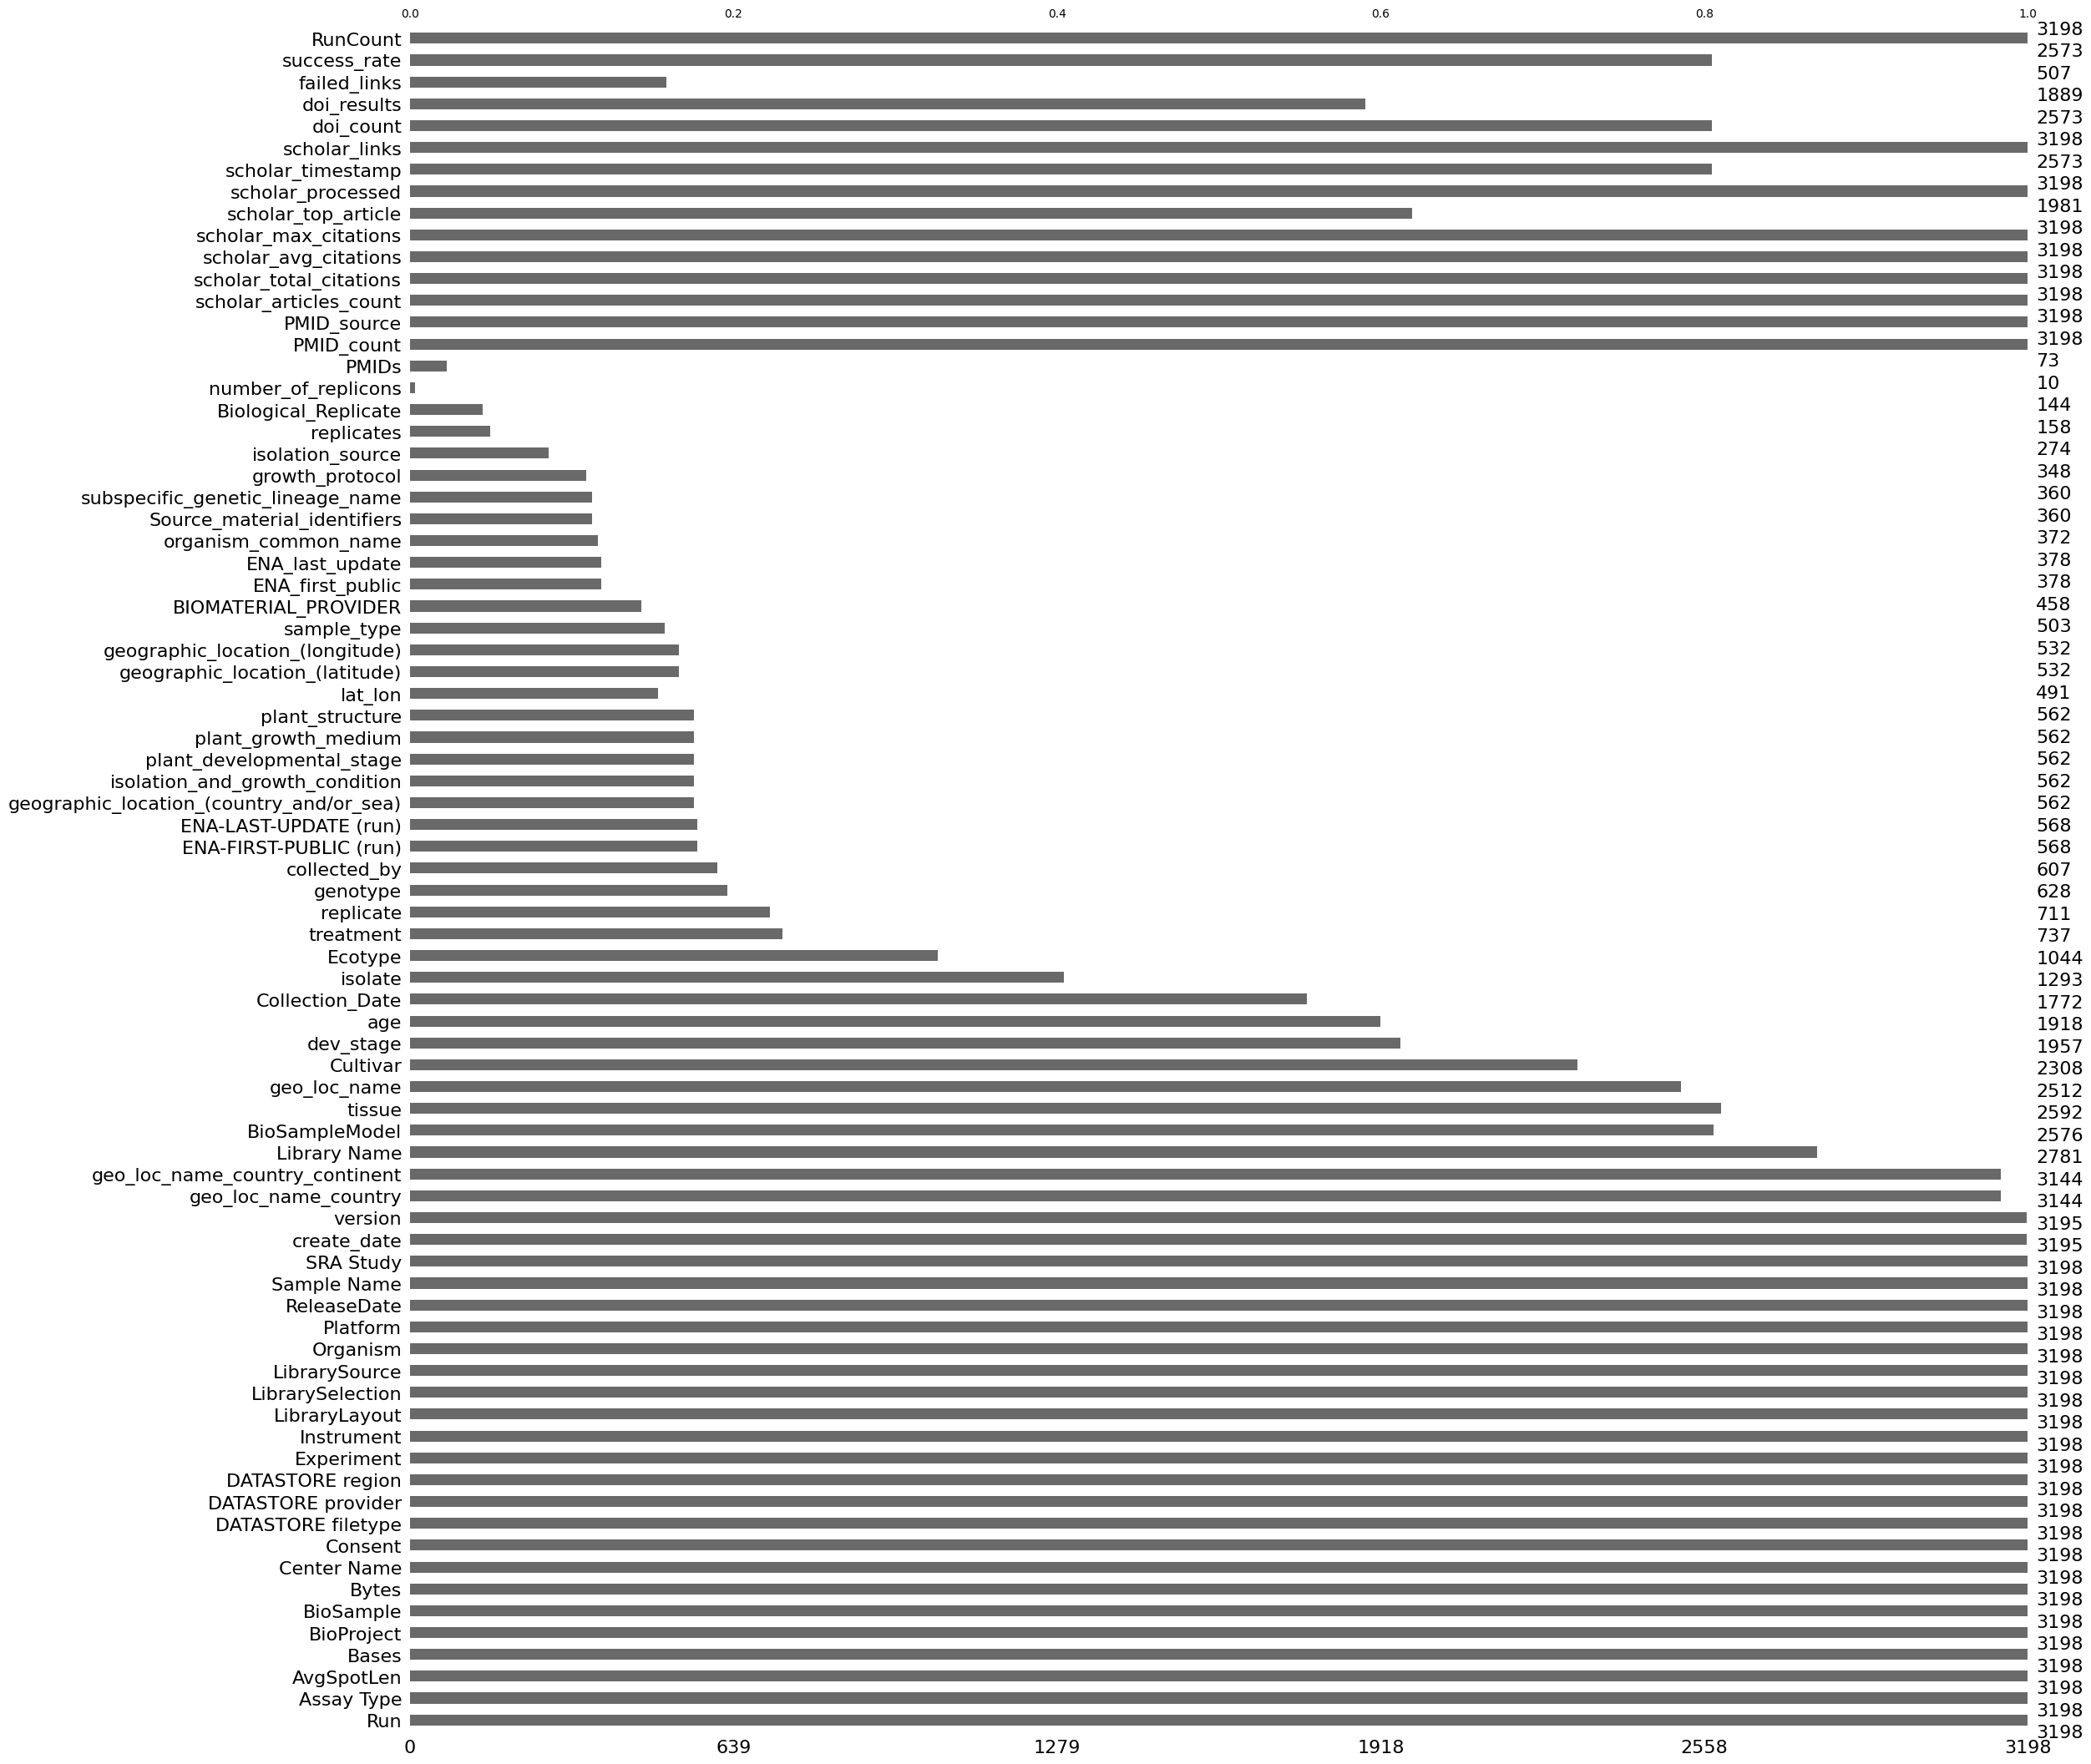

In [10]:
# Visualize missing data pattern
msno.bar(sugarcane_rna_df)

In [12]:
# Verify the organisms present in the dataset
print(sugarcane_rna_df["Organism"].value_counts())

Organism
Saccharum hybrid cultivar                       1550
Saccharum officinarum                            608
Saccharum spontaneum                             220
Saccharum hybrid cultivar SP80-3280              186
Saccharum officinarum x Saccharum spontaneum     129
Acer saccharum                                   117
Saccharum                                        109
Saccharum hybrid cultivar R570                    37
Saccharum hybrid cultivar F36-819                 37
Saccharum hybrid cultivar ROC22                   36
Saccharum hybrid cultivar CP88-1762               30
rhizosphere metagenome                            24
Tripidium arundinaceum                            18
Saccharum hybrid cultivar FN15                    18
Picea glauca                                      16
Sorghum bicolor                                   12
Saccharum hybrid cultivar RB867515                12
Telchin licus                                      7
Saccharum hybrid cultivar Co 86032   

In [13]:
# Remove rows with non sugarcane organism entries (based in the previous output)
non_sugarcane_values = [
    "Acer saccharum",
    "rhizosphere metagenome",
    "Picea glauca",
    "Sorghum bicolor",
    "Telchin licus",
    "Burkholderia seminalis",
    "plant metagenome",
]
sugarcane_rna_df = sugarcane_rna_df[
    ~sugarcane_rna_df["Organism"].isin(non_sugarcane_values)
]
print(sugarcane_rna_df["Organism"].value_counts())

Organism
Saccharum hybrid cultivar                       1550
Saccharum officinarum                            608
Saccharum spontaneum                             220
Saccharum hybrid cultivar SP80-3280              186
Saccharum officinarum x Saccharum spontaneum     129
Saccharum                                        109
Saccharum hybrid cultivar R570                    37
Saccharum hybrid cultivar F36-819                 37
Saccharum hybrid cultivar ROC22                   36
Saccharum hybrid cultivar CP88-1762               30
Saccharum hybrid cultivar FN15                    18
Tripidium arundinaceum                            18
Saccharum hybrid cultivar RB867515                12
Saccharum hybrid cultivar Co 86032                 7
Saccharum robustum                                 6
Saccharum hybrid cultivar GT11                     5
Saccharum hybrid cultivar CP72-2086                5
Name: count, dtype: int64


In [14]:
# Final shape after filtering
sugarcane_rna_df.shape

(3013, 78)

#### Creating the dataframe with only relevant columns

In [15]:
# Check the columns
sugarcane_rna_df.columns

Index(['Run', 'Assay Type', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample',
       'Bytes', 'Center Name', 'Consent', 'DATASTORE filetype',
       'DATASTORE provider', 'DATASTORE region', 'Experiment', 'Instrument',
       'LibraryLayout', 'LibrarySelection', 'LibrarySource', 'Organism',
       'Platform', 'ReleaseDate', 'Sample Name', 'SRA Study', 'create_date',
       'version', 'geo_loc_name_country', 'geo_loc_name_country_continent',
       'Library Name', 'BioSampleModel', 'tissue', 'geo_loc_name', 'Cultivar',
       'dev_stage', 'age', 'Collection_Date', 'isolate', 'Ecotype',
       'treatment', 'replicate', 'genotype', 'collected_by',
       'ENA-FIRST-PUBLIC (run)', 'ENA-LAST-UPDATE (run)',
       'geographic_location_(country_and/or_sea)',
       'isolation_and_growth_condition', 'plant_developmental_stage',
       'plant_growth_medium', 'plant_structure', 'lat_lon',
       'geographic_location_(latitude)', 'geographic_location_(longitude)',
       'sample_type', 'BIOMATERI

In [16]:
# Select the columns
columns = [
    "Run",
    "Assay Type",
    "AvgSpotLen",
    "Bases",
    "BioProject",
    "BioSample",
    "Library Name",
    "Bytes",
    "Center Name",
    "Consent",
    "DATASTORE filetype",
    "DATASTORE provider",
    "DATASTORE region",
    "Experiment",
    "Instrument",
    "LibraryLayout",
    "LibrarySelection",
    "LibrarySource",
    "Organism",
    "Platform",
    "ReleaseDate",
    "Sample Name",
    "SRA Study",
    "create_date",
    "version",
    "BioSampleModel",
    "Collection_Date",
    "doi_results",
    "PMIDs",
    "RunCount",
]

new_columns = [
    "geo_location",
    "growth_conditions",
    "sample_conditions",
    "genotype",
    "replicate",
]
# Create a dataframe with only relevant columns
sugarcane_rna_df_relevant = sugarcane_rna_df[columns]

In [17]:
# Replicate-related columns that may contain information about replicates, which we will combine into a single 'replicate' column.
cols_repl = [
    "replicates",
    "Biological_Replicate",
    "number_of_replicons",
    "replicate",
]

# Create the 'replicate' column by combining the relevant columns, handling missing values and ensuring proper formatting
# Splits the values in the specified columns, removes missing/invalid entries, and concatenates the valid parts with '| ' as a separator.
sugarcane_rna_df_relevant = sugarcane_rna_df_relevant.copy()

# This code creates a new 'replicate' column by combining the values from the specified columns. It handles missing values by treating them as empty strings,
# then concatenates the non-missing values with '| ' as a separator. Finally, it cleans up any trailing separators and replaces empty results with NA.
sugarcane_rna_df_relevant.loc[:, "replicate"] = (
    sugarcane_rna_df[cols_repl]
    .astype(str)
    .replace(["nan", "None", "NaN"], "")
    .agg("| ".join, axis=1)
    .str.strip("| ")
    .str.replace(r"\s*\|\s*$", "", regex=True)
)

# Replace empty strings with NA in the 'replicate' column
sugarcane_rna_df_relevant.loc[:, "replicate"] = sugarcane_rna_df_relevant[
    "replicate"
].replace("", pd.NA)

In [18]:
# Geographic location-related columns that may contain information about the geographic location of the samples, which we will combine into a single 'geo_location' column.
cols_geo = [
    "lat_lon",
    "geographic_location_(latitude)",
    "geographic_location_(longitude)",
    "geo_loc_name",
    "geo_loc_name_country",
    "geo_loc_name_country_continent",
]

# Create the 'geo_location' column by combining the relevant columns, handling missing values and ensuring proper formatting
# This code creates a new 'geo_location' column by combining the values from the specified columns. It handles missing values by treating them as empty strings,
# then concatenates the non-missing values with '| ' as a separator. Finally, it cleans up any trailing separators and replaces empty results with NA.
sugarcane_rna_df_relevant = sugarcane_rna_df_relevant.copy()

sugarcane_rna_df_relevant.loc[:, "geo_location"] = (
    sugarcane_rna_df[cols_geo]
    .astype(str)
    .replace(["nan", "None", "NaN"], "")
    .agg("| ".join, axis=1)
    .str.strip("| ")
    .str.replace(r"\s*\|\s*$", "", regex=True)
)

# Replace empty strings with NA in the 'geo_location' column
sugarcane_rna_df_relevant.loc[:, "geo_location"] = sugarcane_rna_df_relevant[
    "geo_location"
].replace("", pd.NA)

In [19]:
# Growth condition-related columns that may contain information about the growth conditions of the samples, which we will combine into a single 'growth_conditions' column.
cols_cndt = ["isolation_and_growth_condition", "plant_growth_medium", "growth_protocol"]

# Create the 'growth_conditions' column by combining the relevant columns, handling missing values and ensuring proper formatting
# This code creates a new 'growth_conditions' column by combining the values from the specified columns. It handles missing values by treating them as empty strings,
# then concatenates the non-missing values with '| ' as a separator. Finally, it cleans up any trailing separators and replaces empty results with NA.
sugarcane_rna_df_relevant = sugarcane_rna_df_relevant.copy()

sugarcane_rna_df_relevant.loc[:, "growth_conditions"] = (
    sugarcane_rna_df[cols_cndt]
    .astype(str)
    .replace(["nan", "None", "NaN"], "")
    .agg("| ".join, axis=1)
    .str.strip("| ")
    .str.replace(r"\s*\|\s*$", "", regex=True)
)

# Replace empty strings with NA in the 'growth_conditions' column
sugarcane_rna_df_relevant.loc[:, "growth_conditions"] = sugarcane_rna_df_relevant[
    "growth_conditions"
].replace("", pd.NA)

In [21]:
# Treatment-related columns that may contain information about the treatment conditions of the samples, which we will combine into a single 'sample_conditions' column.
cols_treatm = [
    "treatment",
    "tissue",
    "dev_stage",
    "age",
    "isolate",
    "plant_structure",
    "plant_developmental_stage",
    "isolation_source",
]

# Create the 'sample_conditions' column by combining the relevant columns, handling missing values and ensuring proper formatting
# This code creates a new 'sample_conditions' column by combining the values from the specified columns. It handles missing values by treating them as empty strings,
# then concatenates the non-missing values with '| ' as a separator. Finally, it cleans up any trailing separators and replaces empty results with NA.
sugarcane_rna_df_relevant = sugarcane_rna_df_relevant.copy()

sugarcane_rna_df_relevant.loc[:, "sample_conditions"] = (
    sugarcane_rna_df[cols_treatm]
    .astype(str)
    .replace(["nan", "None", "NaN"], "")
    .agg("| ".join, axis=1)
    .str.strip("| ")
    .str.replace(r"\s*\|\s*$", "", regex=True)
)

# Replace empty strings with NA in the 'sample_conditions' column
sugarcane_rna_df_relevant.loc[:, "sample_conditions"] = sugarcane_rna_df_relevant[
    "sample_conditions"
].replace("", pd.NA)

In [22]:
# Genotype-related columns that may contain information about the genotype of the samples, which we will combine
cols_genotype = ["genotype", "Cultivar", "subspecific_genetic_lineage_name"]

# Create the 'genotype' column by combining the relevant columns, handling missing values and ensuring proper formatting
# This code creates a new 'genotype' column by combining the values from the specified columns. It handles missing values by treating them as empty strings,
# then concatenates the non-missing values with '| ' as a separator. Finally, it cleans up any trailing separators and replaces empty results with NA.
sugarcane_rna_df_relevant = sugarcane_rna_df_relevant.copy()

sugarcane_rna_df_relevant.loc[:, "genotype"] = (
    sugarcane_rna_df[cols_genotype]
    .astype(str)
    .replace(["nan", "None", "NaN"], "")
    .agg("| ".join, axis=1)
    .str.strip("| ")
    .str.replace(r"\s*\|\s*$", "", regex=True)
)

# Replace empty strings with NA in the 'genotype' column
sugarcane_rna_df_relevant.loc[:, "genotype"] = sugarcane_rna_df_relevant[
    "genotype"
].replace("", pd.NA)

<Axes: >

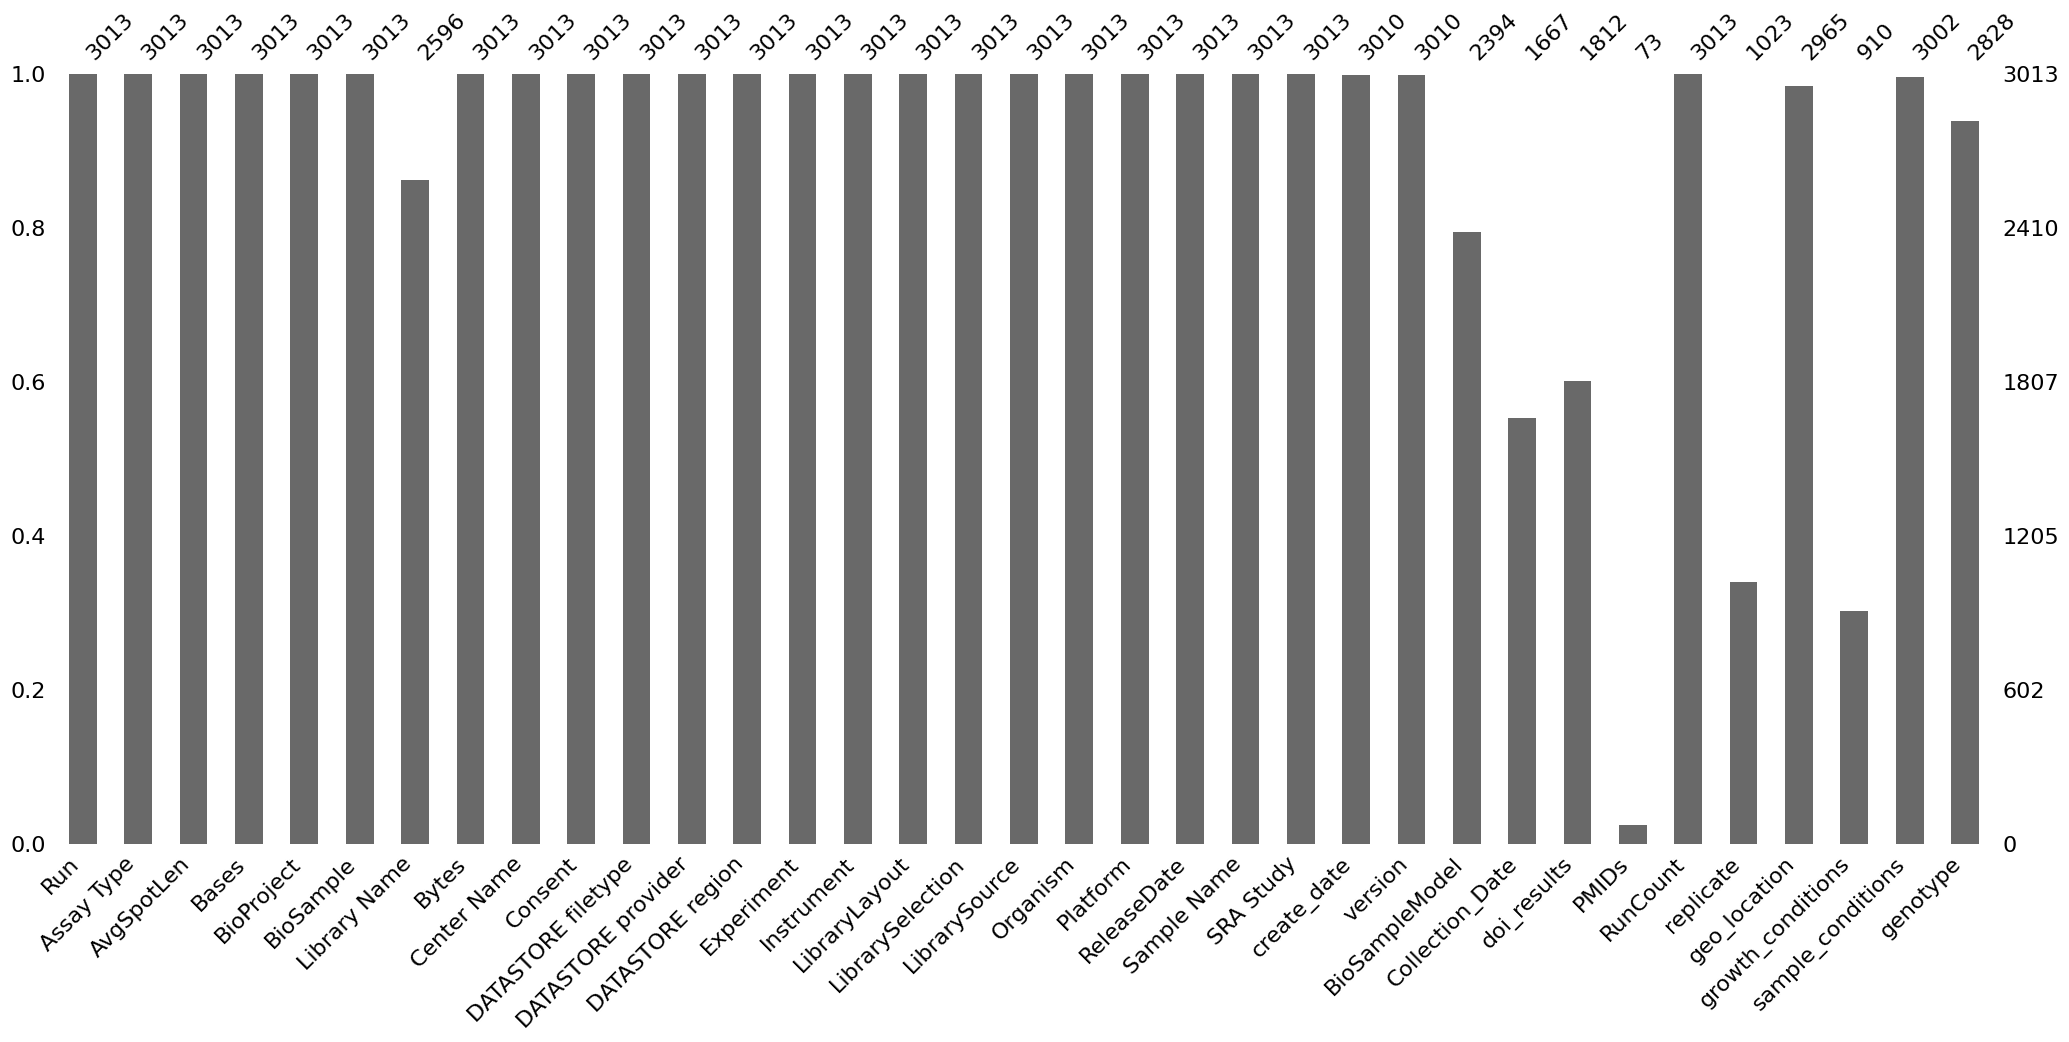

In [23]:
# Visualize missing data pattern in the relevant columns
msno.bar(sugarcane_rna_df_relevant)

In [24]:
# Create new boolean columns indicating whether the original columns had missing values, based on the has_missing_value function
for col in [
    "geo_location",
    "growth_conditions",
    "sample_conditions",
    "genotype",
    "replicate",
]:
    sugarcane_rna_df_relevant[f"{col}_missing"] = sugarcane_rna_df_relevant[col].apply(
        has_missing_value
    )

In [25]:
# Sort dataframe in descending order based in the 'RunCount' column
sugarcane_rna_df_relevant = sugarcane_rna_df_relevant.sort_values(
    by="RunCount", ascending=False
)

In [26]:
sugarcane_rna_df_relevant.to_csv(
    "../raw/sugarcane_rna_relevant_filtered.csv", index=False
)